In [ ]:
!pip install  datasets

TASK 1


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import kagglehub
import os
import pandas as pd
from sklearn.utils import resample

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")
print("Path to dataset files:", path)

# Read datasets
df1 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
df2 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

# Concatenate DataFrames
df = pd.concat([df1, df2], ignore_index=True)

# Clean the data
df = df[["reviews.text", "reviews.rating"]]
df = df.rename(columns={"reviews.text": "text", "reviews.rating": "rating"})
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Map rating to sentiment
def map_sentiment(rating):
    if rating in [1, 2]:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    elif rating in [4, 5]:
        return 2  # Positive

df["sentiment"] = df["rating"].apply(map_sentiment)

# Balance the dataset
df_negative = df[df["sentiment"] == 0]
df_neutral = df[df["sentiment"] == 1]
df_positive = df[df["sentiment"] == 2]

min_count = min(len(df_negative), len(df_neutral), len(df_positive))

df_negative_balanced = resample(df_negative, replace=False, n_samples=min_count, random_state=42)
df_neutral_balanced = resample(df_neutral, replace=False, n_samples=min_count, random_state=42)
df_positive_balanced = resample(df_positive, replace=False, n_samples=min_count, random_state=42)

df_balanced = pd.concat([df_negative_balanced, df_neutral_balanced, df_positive_balanced])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

df_balanced['reviews.text'] = df_balanced['text']
df_balanced.to_csv('task1_data.csv', index=False)

# ✅ Save with sentiment
df_balanced.to_csv('task1_data.csv', index=False)
print("✅ Task 1 data saved as 'task1_data.csv'")
print(df_balanced.head())


Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products
✅ Task 1 data saved as 'task1_data.csv'
                                                text  rating  sentiment  \
0         They're batteries, and they power my stuff       5          2   
1  You need to have amazon prime plus order a spe...       3          1   
2  2nd kindle bought as a gift. Easy to operate, ...       5          2   
3  These are a good price. I don't feel they last...       3          1   
4  This kindle is very slow at recharging. Grandd...       4          2   

                                        reviews.text  
0         They're batteries, and they power my stuff  
1  You need to have amazon prime plus order a spe...  
2  2nd kindle bought as a gift. Easy to operate, ...  
3  These are a good price. I don't feel they last...  
4  This kindle is very slow at recharging. Grandd...  


Trian and test

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets (80% training, 20% validation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],               # Input texts
    df['sentiment'],          # Corresponding sentiment labels
    test_size=0.2,            # 20% of the data will be used for validation
    random_state=42           # Ensures reproducibility
)
# Convert pandas Series to lists for Hugging Face Dataset
train_texts = train_texts.tolist()
val_texts = val_texts.tolist()
train_labels = train_labels.tolist()
val_labels = val_labels.tolist()

# Print the number of samples in each set
print("Number of training samples:", len(train_texts))
print("Number of validation samples:", len(val_texts))


Number of training samples: 15837
Number of validation samples: 3960


In [ ]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    BertModel,
    BertPreTrainedModel,
    BertConfig,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import torch
from torch.nn import CrossEntropyLoss
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split

# ========================
# Step 1: Data Preparation ✅
# ========================

# Optional Data Augmentation for Neutral class
def augment_text(text):
    words = text.split()
    if len(words) > 4:
        random.shuffle(words)
    return ' '.join(words)

neutral_augmented_texts = [augment_text(text) for text in df_balanced[df_balanced['sentiment'] == 1]['text']]
neutral_augmented_labels = [1] * len(neutral_augmented_texts)

texts = list(df_balanced['text']) + neutral_augmented_texts
labels = list(df_balanced['sentiment']) + neutral_augmented_labels

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

train_data = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_data = Dataset.from_dict({"text": val_texts, "label": val_labels})

# ========================
# Step 2: Tokenization ✅
# ========================

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

train_data = train_data.map(tokenize_function, batched=True)
val_data = val_data.map(tokenize_function, batched=True)

train_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# ========================
# Step 3: Class Weights ✅
# ========================

unique_labels = np.array([0, 1, 2])
class_weights = compute_class_weight(class_weight='balanced', classes=unique_labels, y=train_labels)
class_weights[1] *= 4.0  # Boost neutral class weight
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# ========================
# Step 4: Custom Model ✅
# ========================

class WeightedBertForSequenceClassification(BertPreTrainedModel):
    def __init__(self, config, class_weights):
        super().__init__(config)
        self.bert = BertModel(config)
        self.dropout = torch.nn.Dropout(0.3)
        self.classifier = torch.nn.Linear(config.hidden_size, config.num_labels)
        self.class_weights = class_weights
        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fct = CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

config = BertConfig.from_pretrained("bert-base-uncased", num_labels=3)
model = WeightedBertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    config=config,
    class_weights=class_weights_tensor
)

# ========================
# Step 5: Training Arguments ✅
# ========================

training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_steps=50,
    save_total_limit=2,
    report_to="none",
)

# ========================
# Step 6: Trainer ✅
# ========================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# ========================
# Step 7: Train ✅
# ========================

trainer.train()

Map:   0%|          | 0/2787 [00:00<?, ? examples/s]

Map:   0%|          | 0/697 [00:00<?, ? examples/s]

Some weights of WeightedBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.617400,0.509764
2,0.432900,0.451002
3,0.228600,0.540382
4,0.191300,0.595329


TrainOutput(global_step=700, training_loss=0.4169768306187221, metrics={'train_runtime': 77.7361, 'train_samples_per_second': 286.817, 'train_steps_per_second': 18.01, 'total_flos': 733297095207936.0, 'train_loss': 0.4169768306187221, 'epoch': 4.0})

Accuracy: 0.8048780487804879


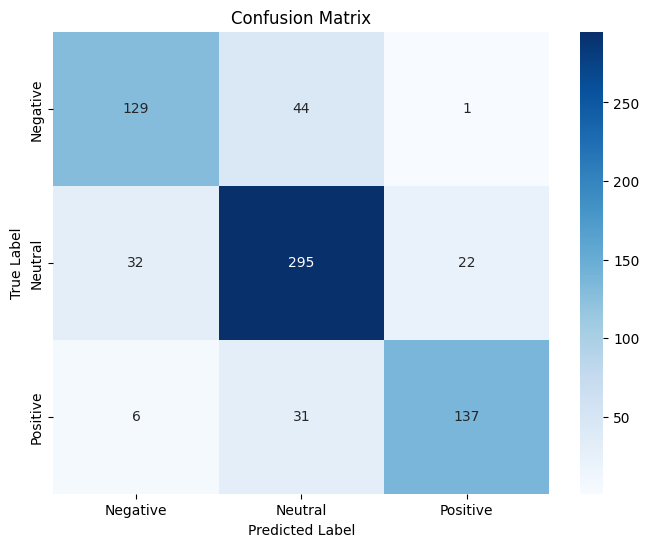


Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.74      0.76       174
     Neutral       0.80      0.85      0.82       349
    Positive       0.86      0.79      0.82       174

    accuracy                           0.80       697
   macro avg       0.81      0.79      0.80       697
weighted avg       0.81      0.80      0.80       697



In [ ]:
# Step 5: Evaluate the model
predictions = trainer.predict(val_data)
preds = predictions.predictions.argmax(axis=-1)

# Make a copy of val_labels as a numpy array for evaluation
val_labels_array = np.array(val_labels)

# Calculate accuracy
print(f"Accuracy: {accuracy_score(val_labels_array, preds)}")

# Generate confusion matrix
conf_matrix = confusion_matrix(val_labels_array, preds)

# Plot confusion matrix visually
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(val_labels_array, preds,
                          target_names=["Negative", "Neutral", "Positive"]))


TASK 2

In [ ]:
import kagglehub
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.utils import resample

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")
print("Path to dataset files:", path)

# List all files in the directory
for file in os.listdir(path):
    print(file)

# Read the datasets
df1 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
df2 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

# Concatenate the two DataFrames
df = pd.concat([df1, df2], ignore_index=True)

# Display the first few rows of the dataset
print(df.head())

# Check the column names
print("Columns:", df.columns.tolist())

# Keep the relevant columns for clustering
df = df[["name", "categories", "brand", "reviews.title", "reviews.text"]]

# Drop missing values in important columns
df.dropna(subset=["name", "categories", "brand"], inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Prepare text column for clustering by merging product information
df["text"] = (
    df["name"].fillna('') + ' ' +
    df["categories"].fillna('') + ' ' +
    df["brand"].fillna('') + ' ' +
    df["reviews.title"].fillna('')
)

# Display sample merged text
print("Sample merged text for clustering:")
print(df["text"].head())

# Vectorize the text data
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['text'])

# Apply KMeans clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# Display cluster distribution
print("\nNumber of products in each cluster:")
print(df['cluster'].value_counts())

# Optional: display basic info about dataset after clustering
print(f"Dataset shape after clustering: {df.shape}")
print(df.head())

# ✅ Save the clustering data for merge
df.to_csv('task2_data.csv', index=False)
print("✅ Task 2 completed and saved as 'task2_data.csv'")


Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv
                     id             dateAdded           dateUpdated  \
0  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
1  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
2  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
3  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
4  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   

                                                name       asins   brand  \
0  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
1  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
2  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
3  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP

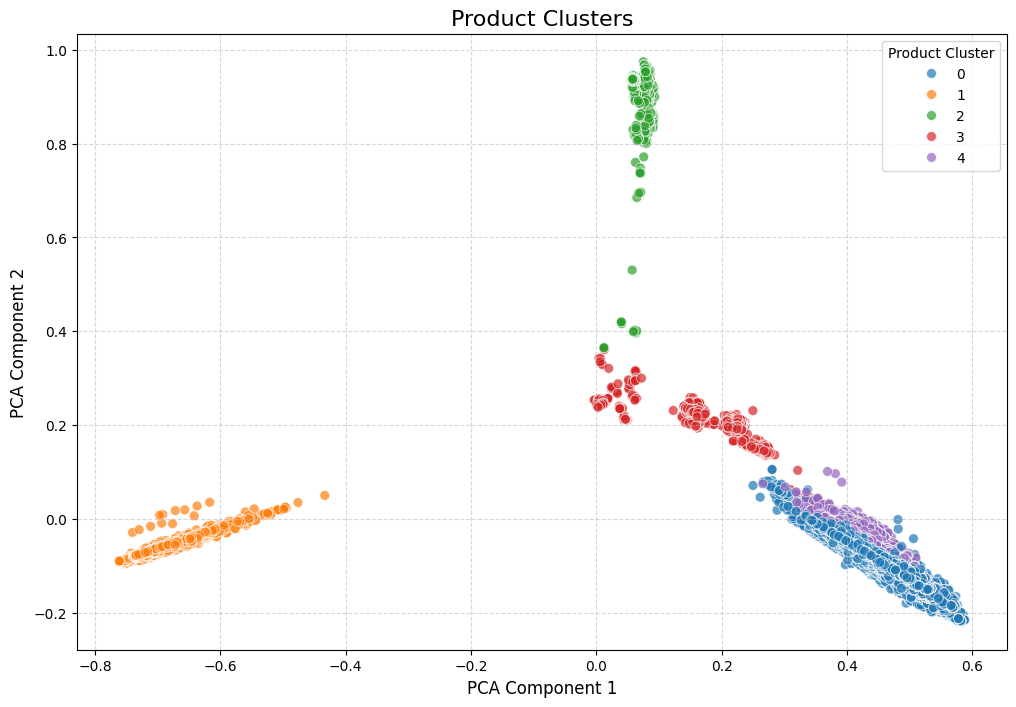


Number of products in each cluster:
cluster
0    11287
1    11266
4     4814
2     2308
3     1497
Name: count, dtype: int64

Top keywords for each cluster:

Cluster 0:
 tablets
 hd
 amazon
 tablet
 computers
 offers
 special
 gb
 display
 16

Cluster 1:
 batteries
 health
 household
 care
 amazonbasics
 camera
 aaa
 aa
 performance
 alkaline

Cluster 2:
 home
 smart
 speakers
 echo
 amazon
 bluetooth
 hub
 audio
 automation
 wireless

Cluster 3:
 kindle
 readers
 reader
 voyage
 tablets
 amazon
 book
 office
 ereaders
 fi

Cluster 4:
 tablets
 kids
 toys
 kid
 amazon
 edition
 proof
 case
 tablet
 computers

Sample products from Cluster 0:

- Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black
- Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black
- Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black
- Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black
- Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Off

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Vectorize the text data
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['text'])

# Step 2: Apply KMeans clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(X)

# Assign cluster labels
df['cluster'] = kmeans.labels_

# Step 3: Visualize clusters with improvements
pca = PCA(n_components=2)
scatter = pca.fit_transform(X.toarray())

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=scatter[:, 0],
    y=scatter[:, 1],
    hue=df['cluster'],
    palette="tab10",
    legend='full',
    s=50,  # increase point size for clarity
    edgecolor='w',  # white edges around points
    alpha=0.7  # transparency
)

plt.title("Product Clusters", fontsize=16)
plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.legend(title="Product Cluster")
plt.grid(True, linestyle='--', alpha=0.5)

# Save the figure as high-quality PNG
plt.savefig("product_clusters.png", dpi=300)

plt.show()

# Step 4: Analyze clusters
print("\nNumber of products in each cluster:")
print(df['cluster'].value_counts())

print("\nTop keywords for each cluster:")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(num_clusters):
    print(f"\nCluster {i}:")
    for ind in order_centroids[i, :10]:
        print(f" {terms[ind]}")

# Step 5: Show sample products from each cluster
for cluster_num in range(num_clusters):
    print(f"\nSample products from Cluster {cluster_num}:\n")
    sample_products = df[df['cluster'] == cluster_num]['name'].head(5).tolist()
    for product in sample_products:
        print(f"- {product}")

# =============================
# Cluster meanings (based on analysis):
# Cluster 0: Regular Tablets (e.g., Fire Tablet, 7 Display)
# Cluster 1: Batteries (e.g., AmazonBasics AAA Batteries)
# Cluster 2: Smart Home Devices (e.g., Amazon Echo Show)
# Cluster 3: Kindle Readers (e.g., Amazon Kindle E-Reader)
# Cluster 4: Kids Tablets (e.g., Fire Kids Edition Tablet)
# =============================


TASK 3


In [ ]:
# Task 3: Merge Task 1 + Task 2 for Summarization

import pandas as pd

print("🚀 Starting Task 3: Merge for summarization")

# Load Task 1 and Task 2 data
df_task1 = pd.read_csv('task1_data.csv')
df_task2 = pd.read_csv('task2_data.csv')

# Prepare merge key (very important: based on reviews.text because it's common between the tasks)
df_task1["merge_key"] = df_task1["text"].str.lower().str.strip()
df_task2["merge_key"] = df_task2["reviews.text"].str.lower().str.strip()

# Merge datasets
df_merged = pd.merge(
    df_task2,
    df_task1[['merge_key', 'rating', 'sentiment']],
    on='merge_key',
    how='left'
)

# ✅ Important: Copy the cluster column from Task 2
df_merged['cluster'] = df_task2['cluster']

# Check and report NaNs
nan_count = df_merged['rating'].isna().sum()
print(f"🔍 Number of NaN in rating after merge: {nan_count}")

# Drop NaN rows to keep only clean data
df_merged_clean = df_merged.dropna(subset=['rating', 'sentiment'])

# Save final cleaned data for summarization
df_merged_clean.to_csv('final_data_ready_for_summary.csv', index=False)

print("✅ Cleaned merged data saved as 'final_data_ready_for_summary.csv'")
print("✅ Task 3 completed and data is ready for summarization ✅")

# Optional: Display sample of the cleaned merged data
print("\n🧩 Sample of cleaned merged data:")
print(df_merged_clean.head())


🚀 Starting Task 3: Merge for summarization
🔍 Number of NaN in rating after merge: 27156
✅ Cleaned merged data saved as 'final_data_ready_for_summary.csv'
✅ Task 3 completed and data is ready for summarization ✅

🧩 Sample of cleaned merged data:
                                                 name  \
0   Amazon Kindle E-Reader 6" Wifi (8th Generation...   
15  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
20  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
22  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
51  Amazon Kindle E-Reader 6" Wifi (8th Generation...   

                                           categories   brand  \
0   Computers,Electronics Features,Tablets,Electro...  Amazon   
15  Computers,Electronics Features,Tablets,Electro...  Amazon   
20  Computers,Electronics Features,Tablets,Electro...  Amazon   
22  Computers,Electronics Features,Tablets,Electro...  Amazon   
51  Computers,Electronics Features,Tablets,Electro...  Amazon   

                   re

In [ ]:
from transformers import pipeline
import pandas as pd


# Load merged data
df = pd.read_csv('final_data_ready_for_summary.csv')

# Use summarization pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Ensure no missing clusters
df = df.dropna(subset=['cluster'])

# Make sure cluster is integer for looping
df['cluster'] = df['cluster'].astype(int)

# Function to summarize reviews for each cluster
def summarize_cluster(cluster_num):
    cluster_data = df[df['cluster'] == cluster_num]

    print("\n" + "=" * 50)
    print(f" Cluster {cluster_num} Summary")
    print("=" * 50)

    # Get the top 3 products by frequency
    top_products = (
        cluster_data.groupby('name')
        .agg(avg_rating=('rating', 'mean'), review_count=('rating', 'count'))
        .sort_values(by='review_count', ascending=False)
        .head(3)
    )

    print("\n Top 3 products:")
    for product, row in top_products.iterrows():
        print(f"- {product} (Rating: {row['avg_rating']:.2f}, Reviews: {row['review_count']})")

    # Get the worst product (lowest average rating)
    worst_product = (
        cluster_data.groupby('name')
        .agg(avg_rating=('rating', 'mean'))
        .sort_values(by='avg_rating')
        .head(1)
    )

    worst_product_name = worst_product.index[0]
    worst_product_rating = worst_product.iloc[0]['avg_rating']

    print("\n Worst product:")
    print(f"- {worst_product_name} (Rating: {worst_product_rating:.2f})")

    # Combine all reviews text into one large string
    combined_reviews = ' '.join(cluster_data['reviews.text'].dropna().tolist())

    # Limit input length for summarizer (max token limit)
    max_input_length = 1024
    combined_reviews = combined_reviews[:max_input_length]

    # Generate summary using Generative AI
    summary = summarizer(combined_reviews, max_length=130, min_length=30, do_sample=False)[0]['summary_text']

    print("\n Summary of reviews:")
    print(summary)

    print("-" * 50)

# Generate summaries for all clusters
for cluster_num in sorted(df['cluster'].unique()):
    summarize_cluster(cluster_num)


Device set to use cuda:0
<ipython-input-86-c44f77c1a8f3>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = df['cluster'].astype(int)



 Cluster 0 Summary

 Top 3 products:
- Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers (Rating: 3.56, Reviews: 200.0)
- All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black (Rating: 3.66, Reviews: 126.0)
- Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Pink Kid-Proof Case (Rating: 3.32, Reviews: 121.0)

 Worst product:
- Amazon Kindle Replacement Power Adapter (Fits Latest Generation Kindle and Kindle DX) For shipment in the U.S only (Rating: 1.33)

 Summary of reviews:
The security, Webroot Anywhere, that was included was impossible to install. I tried calling Geek Squad 4 times for support and was disconnected EVERY time. Decent somewhat slow. Netflix freezes up at times.
--------------------------------------------------

 Cluster 1 Summary

 Top 3 products:
- AmazonBasics AAA Performance Alkaline Batteries (36 Count) (Rating: 2.86, Reviews: 1432.0)
- AmazonBasics AA Performance Alkaline Batteries (48 Count) - P

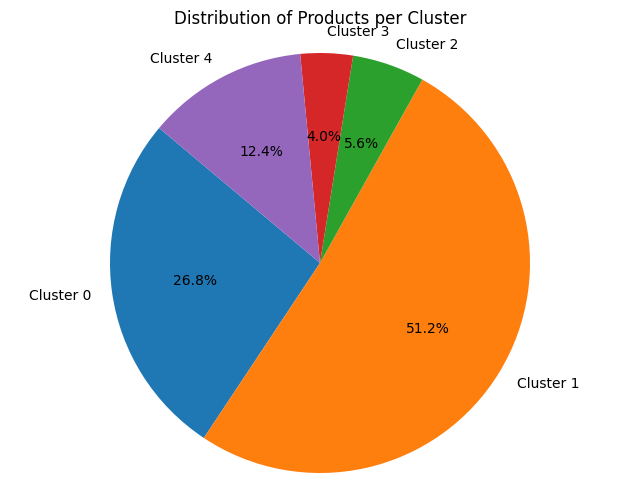

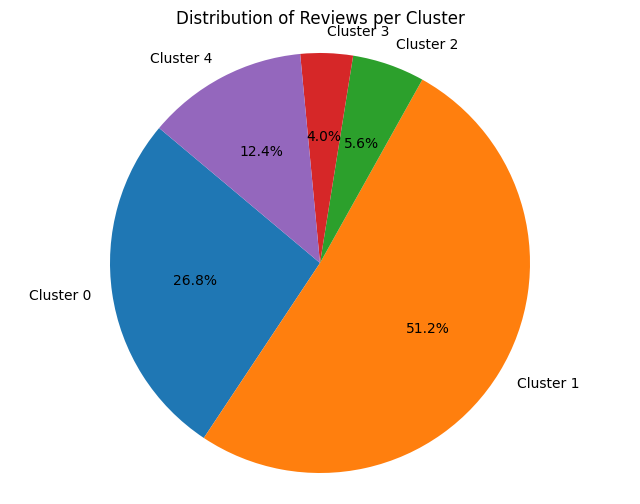

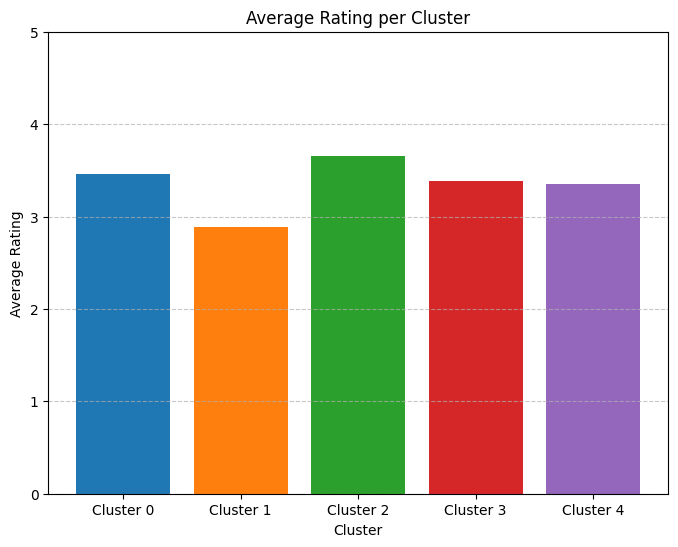

In [ ]:
import matplotlib.pyplot as plt

# Count number of products per cluster
product_counts = df['cluster'].value_counts().sort_index()

# Count number of reviews per cluster
review_counts = df.groupby('cluster')['name'].count()

# Average rating per cluster
average_ratings = df.groupby('cluster')['rating'].mean()

# Define cluster labels
cluster_labels = [f'Cluster {i}' for i in range(len(product_counts))]

# ======================
# Pie Chart: Products per Cluster
# ======================
plt.figure(figsize=(8, 6))
plt.pie(product_counts, labels=cluster_labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Products per Cluster')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# ======================
# Pie Chart: Reviews per Cluster
# ======================
plt.figure(figsize=(8, 6))
plt.pie(review_counts, labels=cluster_labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title('Distribution of Reviews per Cluster')
plt.axis('equal')
plt.show()

# ======================
# Bar Plot: Average Rating per Cluster
# ======================
plt.figure(figsize=(8, 6))
plt.bar(cluster_labels, average_ratings, color=plt.cm.tab10.colors)
plt.title('Average Rating per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Rating')
plt.ylim(0, 5)  # Ratings range from 0 to 5
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
